**exploitation des 150 proteines**

ouvrir le terminal de VS code et y executer :
"pixi add scipy"
"pixi add scipy pot"

ajouter les fichiers .pdb dans le répertoire ''data''

ne pas oublier d'ajouter le fichier globin_all_nn.fst dans le répertoire ''data''

In [15]:
import numpy as np
import Bio.PDB as pdb
from tp_pims.config import TP_PATH
import gudhi as gd
from gudhi import DelaunayCechComplex
from gudhi.wasserstein import wasserstein_distance
from tp_pims.vizualize_filtration import draw_simplicial_complex, get_complexes_filtration
from tp_pims.vizualize_filtration import draw_ca_balls, extract_ca_atom_pos

### Reading multiple proteins

Writing a .json file "proteines_info.json" containing informations about every protein avaible in the 'data' folder, with their amino acid sequences listed in the "globin_all_nn_fst" file.

Informations will be stored in a json file "proteines_info.json".
It contains elements of the class p (for protein)
Such as the AA sequence, protein code, length etc.
More informations can be added and stored in this file for every protein.

A function named "affichage()" 
will allow us to display  cech simplex tree, cech barcode, AA sequence ... 
using it's tag "A123456" 
OR an integer n in [1; number of aviable proteins]
.


In [2]:
import re
from pathlib import Path
from Bio.PDB import PDBParser


dossier_data = TP_PATH / "data"
# parcours des proteines disponibles dans le jeu de données
# on recherche le fichier dans le répertoire
fichier_sequences = None
for chemin in [
    TP_PATH / "globin_all_nn.fst",
    TP_PATH / "data" / "globin_all_nn.fst",
    Path.cwd() / "globin_all_nn.fst",
    TP_PATH.parent / "globin_all_nn.fst"
]:
    if chemin.exists():
        fichier_sequences = chemin
        break

# fonctions à ne pas modifier, récupération des données

def extraire_depuis_fasta(fichier):
    """Extrait les codes et séquences depuis le fichier FASTA globin_all_nn.fst"""
    proteines = []
    code_actuel = ""
    sequence_actuelle = []
    
    with open(fichier, 'r', encoding='utf-8') as f:
        for ligne in f:
            ligne = ligne.strip()
            if not ligne:
                continue
            if ligne.startswith('>'):
                if code_actuel and sequence_actuelle:
                    proteines.append((code_actuel, ''.join(sequence_actuelle)))
                    sequence_actuelle = []
                # Extraction du code (nom de la proteine dans le fichier des sequences en AA)
                match = re.search(r'>[^|]+\|([A-Z0-9]+)', ligne)
                if match:
                    code_actuel = match.group(1)
                else:
                    match = re.search(r'>(\S+)', ligne)
                    code_actuel = match.group(1) if match else ligne[1:].split()[0]
            else:
                if code_actuel:
                    sequence_actuelle.append(ligne)
        if code_actuel and sequence_actuelle:
            proteines.append((code_actuel, ''.join(sequence_actuelle)))
    
    return proteines

def extraire_depuis_fichiers_pdb(dossier):
    """Extrait les codes depuis les noms des fichiers PDB"""
    codes = []
    for pdb_file in dossier.glob("AF-*.pdb"):
        match = re.search(r'AF-([A-Z0-9]+)-F1-model_v6\.pdb', pdb_file.name)
        if match:
            codes.append(match.group(1))
    return codes


# vérification du traitement de fichier

print("=========================")
print("CHARGEMENT DES PROTÉINES")
print("=========================")

# Chargement des séquences depuis le fichier FASTA "globin_all_nn.fst"
proteines_avec_sequences = []
if fichier_sequences:
    print(f"Fichier FASTA trouvé: {fichier_sequences.name}")
    proteines_avec_sequences = extraire_depuis_fasta(fichier_sequences)
    print(f"   → {len(proteines_avec_sequences)} protéines avec séquences")
else:
    print("Fichier FASTA non trouvé, utilisation des fichiers PDB uniquement")

# liste des fichiers PDB disponibles
print(f"\n Dossier data: {dossier_data}")
fichiers_pdb = list(dossier_data.glob("AF-*.pdb"))
print(f"   → {len(fichiers_pdb)} fichiers PDB trouvés")

# codes extraits depuis les fichiers PDB
codes_pdb = extraire_depuis_fichiers_pdb(dossier_data)
print(f"   → {len(codes_pdb)} codes extraits des fichiers PDB")


# création de classes pour gérer les données facilement

class Proteine:
    """Classe représentant une protéine avec accès facile"""
    def __init__(self, code, sequence=None):
        self.code = code
        self.sequence = sequence
        self.nom_fichier = f"AF-{code}-F1-model_v6.pdb"
        self.chemin = dossier_data / self.nom_fichier
        self.fichier_existe = self.chemin.exists()
        self.longueur = len(sequence) if sequence else None
    
    def charger_structure(self):
        """Charge la structure PDB avec PDBParser"""
        if not self.fichier_existe:
            print(f"Fichier non trouvé: {self.chemin}")
            return None
        parser = PDBParser(PERMISSIVE=1)
        return parser.get_structure(id=self.code, file=self.chemin.open("r"))
    
    def __repr__(self):
        return f"Proteine('{self.code}', existe={self.fichier_existe})"

# Créer le dictionnaire principal d'accès
proteines = {}

# Ajoute les protéines avec séquences (priorité)
for code, seq in proteines_avec_sequences:
    proteines[code] = Proteine(code, seq)

# Ajoute aussi les protéines des fichiers PDB qui n'étaient pas dans le FASTA
for code in codes_pdb:
    if code not in proteines:
        proteines[code] = Proteine(code)


# AFFICHAGE RÉSUMÉ

print("\n" + "======================")
print("RÉSUMÉ DES PROTÉINES CHARGÉES")
print("==================")

proteines_avec_fichier = sum(1 for p in proteines.values() if p.fichier_existe)
proteines_avec_seq = sum(1 for p in proteines.values() if p.sequence)

print(f"Total protéines: {len(proteines)}")
print(f"Avec fichier PDB: {proteines_avec_fichier}")
print(f"Avec séquence AA: {proteines_avec_seq}")

# Afficher l'ensemble des proteines
print("\n Premier aperçu (limite maximale de 200 modifiable):")
for i, (code, p) in enumerate(list(proteines.items())[:200], 1):
    statut = "trouvé" if p.fichier_existe else "fichier introuvable"
    seq_info = f"({p.longueur} aa)" if p.longueur else "sans séquence"
    print(f"   {i}. {code:<20} {statut} {p.nom_fichier:<45} {seq_info}")


# FONCTIONS D'ACCÈS (MODIFIABLES)

def get_proteine(code):
    """Récupère une protéine par son code"""
    return proteines.get(code)

def get_proteines_avec_fichier():
    """Retourne la liste des protéines dont le fichier PDB existe"""
    return [p for p in proteines.values() if p.fichier_existe]

def get_proteines_avec_sequence():
    """Retourne la liste des protéines avec séquence"""
    return [p for p in proteines.values() if p.sequence]

def charger_proteine(code):
    """Charge directement la structure PDB d'une protéine"""
    p = get_proteine(code)
    if p:
        return p.charger_structure()
    print(f"ATTENTION Protéine {code} non trouvée")
    return None






# Afficher les premiers codes disponibles pour copier/coller
print("\n" + "======================================" )
print("CODES DISPONIBLES (pour copier/coller ou identifier la proteine)")
print("============================" )
codes_disponibles = [p.code for p in get_proteines_avec_fichier()]
if codes_disponibles:
    print(f"codes = {codes_disponibles[:20]}")
    if len(codes_disponibles) > 20:
        print(f"# ... et {len(codes_disponibles)-20} autres")
else:
    print("Aucun code disponible")

# Sauvegarde pour utilisation ultérieure
# il est possible d'ajouter des caracteristiques 

import json
with open(TP_PATH / "proteines_info.json", 'w') as f:
    json.dump({
        code: {
            'code': p.code,
            'nom_fichier': p.nom_fichier,
            'chemin': str(p.chemin),
            'fichier_existe': p.fichier_existe,
            'sequence' : p.sequence,
            'longueur': p.longueur
        }
        for code, p in proteines.items()
    }, f, indent=2)
print(f"\n Informations sauvegardées dans: {TP_PATH / 'proteines_info.json'}")

print("\n Utilisez les fonctions ci-dessous pour accéder aux protéines.")



CHARGEMENT DES PROTÉINES
Fichier FASTA trouvé: globin_all_nn.fst
   → 152 protéines avec séquences

 Dossier data: C:\Users\etulyon1\Documents\PIMS\src\tp_pims\data
   → 153 fichiers PDB trouvés
   → 153 codes extraits des fichiers PDB

RÉSUMÉ DES PROTÉINES CHARGÉES
Total protéines: 153
Avec fichier PDB: 153
Avec séquence AA: 152

 Premier aperçu (limite maximale de 200 modifiable):
   1. A0A0A8WJC6           trouvé AF-A0A0A8WJC6-F1-model_v6.pdb                 (136 aa)
   2. A0A0K3AT43           trouvé AF-A0A0K3AT43-F1-model_v6.pdb                 (546 aa)
   3. A0A2H4ZEZ2           trouvé AF-A0A2H4ZEZ2-F1-model_v6.pdb                 (144 aa)
   4. A0AAJ7SV95           trouvé AF-A0AAJ7SV95-F1-model_v6.pdb                 (1255 aa)
   5. A0AAJ7T5N9           trouvé AF-A0AAJ7T5N9-F1-model_v6.pdb                 (233 aa)
   6. A0AAJ7TMY1           trouvé AF-A0AAJ7TMY1-F1-model_v6.pdb                 (253 aa)
   7. A0AAJ7U215           trouvé AF-A0AAJ7U215-F1-model_v6.pdb                

**Affichage des caractéristiques de la première protéine**

=-=-=-=-=-=-=(AFFICHAGE : A0A0A8WJC6)=-=-=-=-=-=-=
 Fichier : 
AF-A0A0A8WJC6-F1-model_v6.pdb
 Séquence D'acides Aminés : 
IEALQDIWEKVFKSAEDVGVIILVRLFTGHPASKQYFAMFKDLETANDLKASAKLRWHAGRVMGSLDKAVRSLRNPEKLIQILHAVGLSHARQATPVDVKYYHILGGIIMDVLLETFKDEMSPTARGAWTKLLGTL
 Nombre d'AA : 136
diagramme de persisatance de A0A0A8WJC6


c:\Users\etulyon1\Documents\PIMS\.pixi\envs\default\Lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


barcode de persistance de A0A0A8WJC6
=-=-=-=-=-=-=(protéine A0A0A8WJC6 ^)=-=-=-=-=-=-=
.


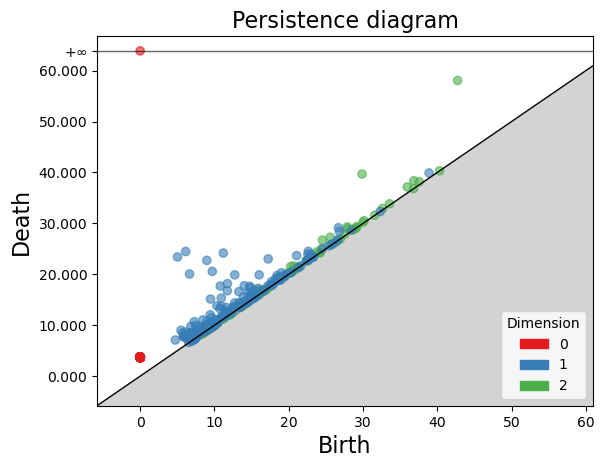

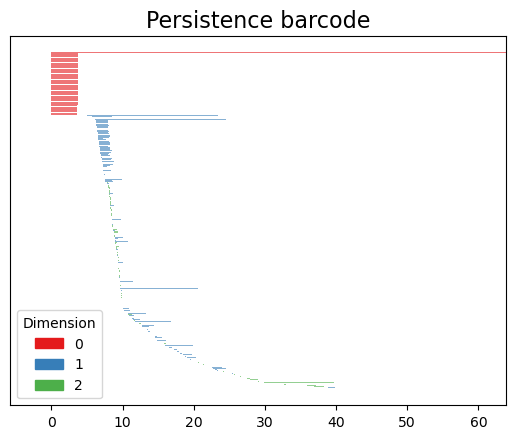

In [3]:

parser = pdb.PDBParser(PERMISSIVE=1)

p = get_proteine('A0A0A8WJC6')

protein = parser.get_structure(id=0, file=(TP_PATH / "data" / p.nom_fichier).open("r"))

whole_protein = list(protein)
pos_ca = extract_ca_atom_pos(whole_protein)

cech_cs = DelaunayCechComplex(points = pos_ca)
cech_simplex_tree_sample = cech_cs.create_simplex_tree() 
cech_barcode = cech_simplex_tree_sample.persistence()

print(f"=-=-=-=-=-=-=(AFFICHAGE : {p.code})=-=-=-=-=-=-=")
print(" Fichier : ") 
print(p.nom_fichier) 
print(" Séquence D'acides Aminés : ")
print(p.sequence)  
print(f" Nombre d'AA : {p.longueur}") 
print(f"diagramme de persisatance de {p.code}")
gd.plot_persistence_diagram(cech_barcode);
print(f"barcode de persistance de {p.code}")
gd.plot_persistence_barcode(cech_barcode);
print(f"=-=-=-=-=-=-=(protéine {p.code} ^)=-=-=-=-=-=-=")
print(".")




To Browse Proteins using their code or positions in the Json folder :

In [4]:
def get_position(code):
    
    import json
    with open(TP_PATH / "positions_mapping.json", 'r') as f:
        mapping = json.load(f)
    
    code_to_pos = {v: int(k) for k, v in mapping.items()}
    return code_to_pos.get(code, None)



def get_code(position):
    import json
    with open(TP_PATH / "positions_mapping.json", 'r') as f:
        mapping = json.load(f)
    return mapping.get(str(position), None)



In [5]:
get_position('A0A0A8WJC6')


1

In [6]:
get_code(1)

'A0A0A8WJC6'

**fonction d'affichage**

In [7]:
def affiche(param):

    
    # Conversion position → code si nécessaire
    if isinstance(param, int):
        with open(TP_PATH / "positions_mapping.json", 'r') as f:
            code = json.load(f).get(str(param))
    else:
        code = param
    
    # Récupération et traitement
    p = get_proteine(code)
    parser = PDBParser(PERMISSIVE=1)
    protein = parser.get_structure(id=0, file=(TP_PATH / "data" / p.nom_fichier).open("r"))
    pos_ca = extract_ca_atom_pos(list(protein))
    
    cech_cs = gd.DelaunayCechComplex(points=pos_ca)
    cech_barcode = cech_cs.create_simplex_tree().persistence()
    
    # Affichage
    print(f"=-=-= AFFICHAGE : {p.code} =-=-=")
    print("Fichier :", p.nom_fichier)
    print("Séquence :", p.sequence)
    print(f"longueur {p.longueur}")
    gd.plot_persistence_diagram(cech_barcode)
    gd.plot_persistence_barcode(cech_barcode)
    print(f"=-=-= fin {p.code} =-=-=")

=-=-= AFFICHAGE : A3RMS5 =-=-=
Fichier : AF-A3RMS5-F1-model_v6.pdb
Séquence : MNETTVGVGKMYEEFRITQLVNETLTTVIEKVQTNHEKISTKAKPRPLSAINEEIREYDQLSRELEKDYRRSMRIVDDDFELARTHWIQLQKSNKQGLAIRGCFLTMLEKYPQVRPIWGFGKRIEGRGDETWKPEIVEDFYFRHHCASLQAALNMIIQNKDDKSGMRRMLNEMGAHHFFYDACEPHFEVFQDSLLESMKLVLNGGDSLDDDIEQSWICLLQTIRLHMGEGIEIQRANYLTQCLIPKEMEEVRANWMQVENYGFRKAGLLLCQSAFDNYSELLKTHNLSMTLPIEANKTSDSFVALSDQIMQALDKTIQSYTPEEGFLNLIQEIKDFVIKFLVVEVCPPLIRKSFIDGLIHMLCKILSIKHVKEDFLHIWKKVYRVMEQAMVANIVEY
longueur 397
=-=-= fin A3RMS5 =-=-=


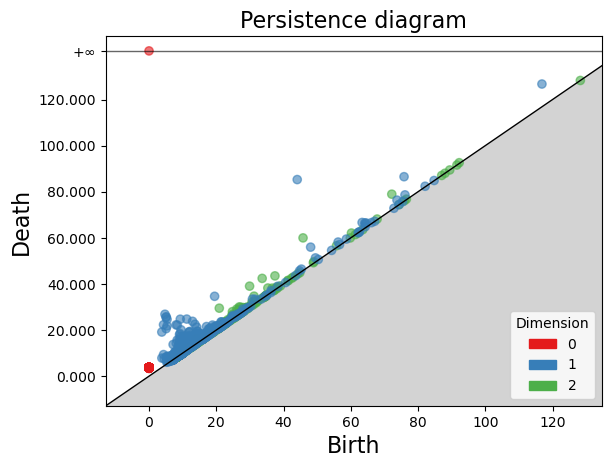

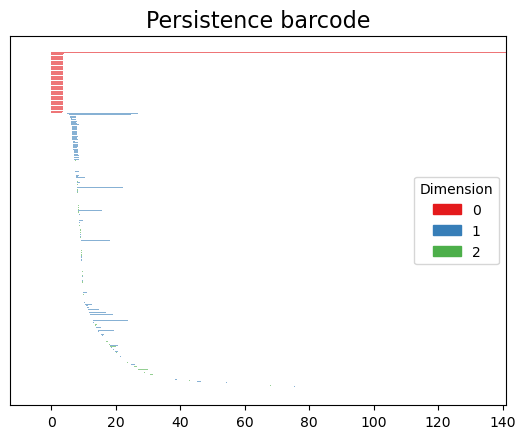

In [8]:
affiche(10)

**fonction de comparaison par WASSERSTEIN** (entre deux protéines saisies par l'utilisateur)

In [9]:
import matplotlib.pyplot as plt

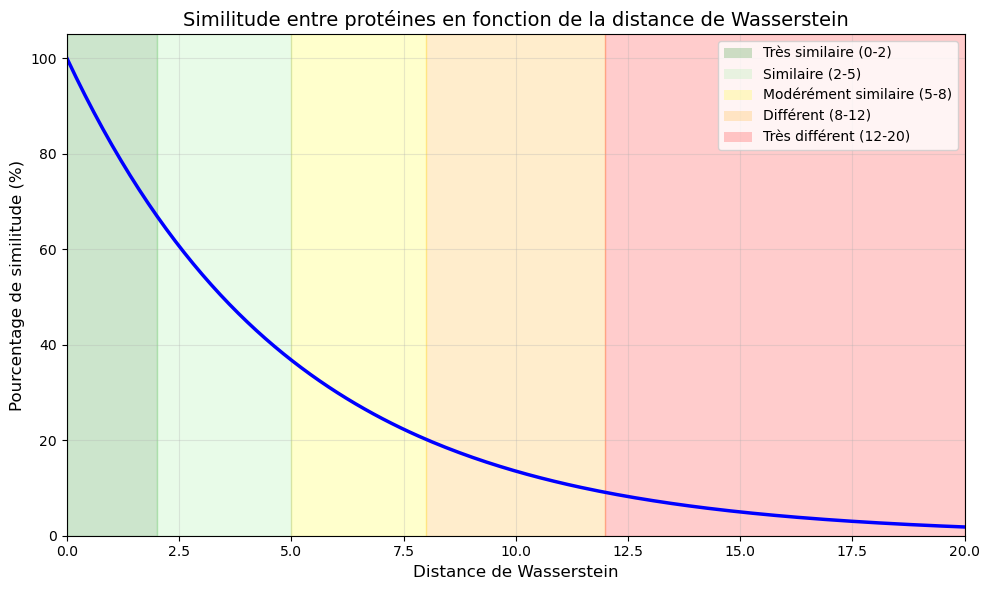

In [10]:

def plot_similitude_vs_distance():
    """
    Graphique simple de la similitude en fonction de la distance de Wasserstein
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Données
    distances = np.linspace(0, 20, 200)
    similitude = 100 * np.exp(-distances / 5)
    
    # Création du graphique
    plt.figure(figsize=(10, 6))
    plt.plot(distances, similitude, 'b-', linewidth=2.5)
    
    # Personnalisation
    plt.xlabel('Distance de Wasserstein', fontsize=12)
    plt.ylabel('Pourcentage de similitude (%)', fontsize=12)
    plt.title('Similitude entre protéines en fonction de la distance de Wasserstein', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 20)
    plt.ylim(0, 105)
    
    # Ajout des zones
    plt.axvspan(0, 2, alpha=0.2, color='green')
    plt.axvspan(2, 5, alpha=0.2, color='lightgreen')
    plt.axvspan(5, 8, alpha=0.2, color='yellow')
    plt.axvspan(8, 12, alpha=0.2, color='orange')
    plt.axvspan(12, 20, alpha=0.2, color='red')
    
    # Légende des zones
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.2, label='Très similaire (0-2)'),
        Patch(facecolor='lightgreen', alpha=0.2, label='Similaire (2-5)'),
        Patch(facecolor='yellow', alpha=0.2, label='Modérément similaire (5-8)'),
        Patch(facecolor='orange', alpha=0.2, label='Différent (8-12)'),
        Patch(facecolor='red', alpha=0.2, label='Très différent (12-20)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Utilisation
plot_similitude_vs_distance()

formule : 100*e^(-n/5)  avec n la valeur de la distance de wasserstein 2

il est possible d'utiliser à la place une fonction linéaire voire logarithmique si on veut ajuster le taux de similitude pour des protéïnes proches en séquence mais éloignées en structure 3D par exemple.

Fonction de comparaison entre deux protéines :

In [11]:

def compare_proteines(param1, param2):
    """
    Compare deux protéines et calcule les distances entre leurs diagrammes de persistance.
    
    Paramètres:
        param1: soit code (str) soit position (int) de la première protéine
        param2: soit code (str) soit position (int) de la deuxième protéine
    
    Retourne:
        dict: Dictionnaire contenant les caractéristiques et les distances etc.
    """
    
    # on récupère la protéine
    def get_proteine_from_param(param):
        """Convertit un paramètre (code ou position) en objet Proteine"""
        if isinstance(param, int):  # Position
            with open(TP_PATH / "positions_mapping.json", 'r') as f:
                mapping = json.load(f)
            code = mapping.get(str(param))
            if not code:
                print(f" Position {param} non trouvée")
                return None
            print(f" Position {param} → Code: {code}")
        else:  # Code
            code = param
        
        # Récupérer la Proteine
        p = get_proteine(code)
        if not p:
            print(f" Protéine {code} non trouvée")
            return None
        return p
    
    
    # fonction qui extrait les données d'une protéine
   
    def traiter_proteine(p):
        """Traite une protéine et retourne ses caractéristiques et son diagramme"""
        print(f"\n Traitement de {p.code}...")
        
        # Charger la structure
        parser = PDBParser(PERMISSIVE=1)
        protein = parser.get_structure(id=0, file=p.chemin.open("r"))
        
        # Extraire les positions des atomes CA
        whole_protein = list(protein)
        pos_ca = extract_ca_atom_pos(whole_protein)
        
        # Calcul du complexe de Delaunay-Cech
        cech_cs = gd.DelaunayCechComplex(points=pos_ca)
        cech_simplex_tree = cech_cs.create_simplex_tree()
        
        # Calcul du diagramme de persistance
        cech_simplex_tree.compute_persistence()
        
        # Extraire le diagramme de persistance en dimension 1
        diagram = cech_simplex_tree.persistence_intervals_in_dimension(1)
        
        # Convertir en tableau numpy pour wasserstein
        # Filtrer les points infinis et convertir en numpy array
        diagram_filtered = []
        for d in diagram:
            if d[1] != float('inf') and not np.isinf(d[0]) and not np.isinf(d[1]):
                diagram_filtered.append([d[0], d[1]])
        
        diagram_np = np.array(diagram_filtered) if diagram_filtered else np.array([]).reshape(0, 2)
        
        return {
            'code': p.code,
            'nom_fichier': p.nom_fichier,
            'sequence': p.sequence,
            'longueur': p.longueur,
            'nb_atomes_CA': len(pos_ca),
            'diagram': diagram_np,
            'diagram_raw': diagram,
            'simplex_tree': cech_simplex_tree
        }
    
    
    print("\n" + "=====================")
    print("COMPARAISON DE DEUX PROTÉINES")
    print("====================")
    
    p1 = get_proteine_from_param(param1)
    p2 = get_proteine_from_param(param2)
    
    if not p1 or not p2:
        print("Impossible de comparer : une ou deux protéines non trouvées")
        return None
    
    
    data1 = traiter_proteine(p1)
    data2 = traiter_proteine(p2)
    
    


    diagram1 = data1['diagram']
    diagram2 = data2['diagram']
    
    print("\n" + "===============================")
    print("DISTANCES ENTRE DIAGRAMMES DE PERSISTANCE")
    print("=========================")
    
    # Vérifier que les diagrammes ne sont pas vides
    if len(diagram1) > 0 and len(diagram2) > 0:
        try:
            # Distance de Wasserstein (ordre 2)
            wass_dist_2 = wasserstein_distance(diagram1, diagram2, order=2)
            print(f"Distance de Wasserstein (ordre 2) : {wass_dist_2:.4f}")
            
            # Distance de Wasserstein (ordre 1)
            wass_dist_1 = wasserstein_distance(diagram1, diagram2, order=1)
            print(f"Distance de Wasserstein (ordre 1) : {wass_dist_1:.4f}")
        except Exception as e:
            print(f"Erreur calcul Wasserstein: {e}")
            wass_dist_2 = None
            wass_dist_1 = None
    else:
        print("Un des diagrammes est vide, impossible de calculer Wasserstein")
        wass_dist_2 = None
        wass_dist_1 = None
    
    # Distance Bottleneck (toujours disponible)
    try:
        # Pour bottleneck, on peut utiliser les diagrammes raw
        diagram1_raw = data1['diagram_raw']
        diagram2_raw = data2['diagram_raw']
        diagram1_raw = [d for d in diagram1_raw if d[1] != float('inf')]
        diagram2_raw = [d for d in diagram2_raw if d[1] != float('inf')]
        
        if len(diagram1_raw) > 0 and len(diagram2_raw) > 0:
            bottleneck_dist = gd.bottleneck_distance(diagram1_raw, diagram2_raw)
            print(f" Distance Bottleneck : {bottleneck_dist:.4f}")
        else:
            bottleneck_dist = None
            print(" Un des diagrammes est vide, impossible de calculer Bottleneck")
    except Exception as e:
        print(f" Erreur calcul Bottleneck: {e}")
        bottleneck_dist = None
    
    # Interprétation
    
        
    if wass_dist_2 is not None:
        print("\n INTERPRÉTATION (Wasserstein-2):")
        
        # Calcul du pourcentage de similitude (formule exponentielle décroissante)
        # Plus la distance est petite, plus la similitude est élevée
        if wass_dist_2 <= 0:
            pourcentage_similitude = 100.0
        else:
            # Utilisation d'une fonction exponentielle: similitude = 100 * e^(-distance / facteur)
            # 
            
            pourcentage_similitude = 100 * np.exp(-wass_dist_2 / 5)

        print(f"Pourcentage de similitude : {pourcentage_similitude:.1f}%")
    
        
        # Interprétation textuelle basée sur le pourcentage
        if pourcentage_similitude >= 80:
            print("Interprétation : Les deux protéines sont TRÈS SIMILAIRES")
           
        elif pourcentage_similitude >= 60:
            print("Interprétation : Les deux protéines sont SIMILAIRES")
            
        elif pourcentage_similitude >= 40:
            print(" Interprétation : Les deux protéines sont MODÉRÉMENT SIMILAIRES")
            
        elif pourcentage_similitude >= 20:
            print("Interprétation : Les deux protéines sont DIFFÉRENTES")
            
        else:
            print("Interprétation : Les deux protéines sont TRÈS DIFFÉRENTES")
            
        
        
        print("Plus la distance de wasserstein est petite, plus les protéines sont similaires")
    
    # ============================================
    # AFFICHAGE DES CARACTÉRISTIQUES COMPARÉES
    # ============================================
    print("\n" + "===============")
    print("CARACTÉRISTIQUES COMPARÉES")
    print("===============")
    
    # En-tête
    print(f"{'Caractéristique':<25} {'Protéine 1':<30} {'Protéine 2':<30}")
    print("---------------------------------")
    
    # Code
    print(f"{'Code':<25} {data1['code']:<30} {data2['code']:<30}")
    
    # Fichier
    print(f"{'Fichier PDB':<25} {data1['nom_fichier']:<30} {data2['nom_fichier']:<30}")
    
    # Longueur
    print(f"{'Longueur (aa)':<25} {data1['longueur']:<30} {data2['longueur']:<30}")
    
    # Nombre d'atomes CA
    print(f"{'Nb atomes CA':<25} {data1['nb_atomes_CA']:<30} {data2['nb_atomes_CA']:<30}")
    
    # Points dans le diagramme
    print(f"{'Points diagramme':<25} {len(data1['diagram_raw']):<30} {len(data2['diagram_raw']):<30}")
    
    # Séquence (aperçu)
    #seq1 = data1['sequence'][:50] + "..." if data1['sequence'] and len(data1['sequence']) > 50 else str(data1['sequence'])
    #seq2 = data2['sequence'][:50] + "..." if data2['sequence'] and len(data2['sequence']) > 50 else str(data2['sequence'])
    #print(f"{'Séquence (aperçu)':<25} {seq1:<30} {seq2:<30}")
    
    
    
    # ============================================
    # VISUALISATION DES DIAGRAMMES
    # ============================================
    print("\n" + "=====================")
    print("VISUALISATION DES DIAGRAMMES DE PERSISTANCE")
    print("=================")
    
    # Diagramme de la protéine 1
    print(f"\n Diagramme de persistance - {data1['code']}")
    if len(data1['diagram_raw']) > 0:
        fig, ax = plt.subplots(figsize=(10, 8))
        gd.plot_persistence_diagram(data1['diagram_raw'], axes=ax)
        ax.set_title(f'Diagramme de persistance - {data1["code"]}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    else:
        print("   (Diagramme vide)")
    
    # Diagramme de la protéine 2
    print(f"\n Diagramme de persistance - {data2['code']}")
    if len(data2['diagram_raw']) > 0:
        fig, ax = plt.subplots(figsize=(10, 8))
        gd.plot_persistence_diagram(data2['diagram_raw'], axes=ax)
        ax.set_title(f'Diagramme de persistance - {data2["code"]}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("   (Diagramme vide)")
    
    
        # Barcode de la protéine 1
    print(f"\n Barcode - {data1['code']}")
    if len(data1['diagram_raw']) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        gd.plot_persistence_barcode(data1['diagram_raw'], axes=ax)
        ax.set_title(f'Barcode de persistance - {data1["code"]}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Persistance')
        ax.set_ylabel('Points')
        plt.tight_layout()
        plt.show()
    else:
        print("   (Barcode vide)")
    
    # Barcode de la protéine 2
    print(f"\n Barcode - {data2['code']}")
    if len(data2['diagram_raw']) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        gd.plot_persistence_barcode(data2['diagram_raw'], axes=ax)
        ax.set_title(f'Barcode de persistance - {data2["code"]}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Persistance')
        ax.set_ylabel('Points')
        plt.tight_layout()
        plt.show()
    else:
        print("   (Barcode vide)")
    

    
    # Retourner les résultats - utile pour d'autres programmes de comparaison
    # qui pourraient utiliser ces données
    return {
        'proteine1': data1['code'],
        'proteine2': data2['code'],
        'longueur1': data1['longueur'],
        'longueur2': data2['longueur'],
        'points_diagram1': len(data1['diagram_raw']),
        'points_diagram2': len(data2['diagram_raw']),
        'wasserstein_2': wass_dist_2,
        'wasserstein_1': wass_dist_1,
        'bottleneck': bottleneck_dist,
        'diagram1': data1['diagram_raw'],
        'diagram2': data2['diagram_raw']
    }


print("\n" + "=============")
print(" EXEMPLES D'UTILISATION")
print("=============")

print("""
# Comparer deux protéines par leur position
resultat = compare_proteines(1, 2)

# Comparer deux protéines par leur code
resultat = compare_proteines('A0A0A8WJC6', 'A0A0K3AT43')

# Récupérer uniquement la distance de Wasserstein
resultat = compare_proteines(1, 2)
if resultat and resultat['wasserstein_2']:
    print(f"Distance: {resultat['wasserstein_2']}")
""")
# mais pour cela j'ai codé wasserstein_proteines() qui marche mieux





 EXEMPLES D'UTILISATION

# Comparer deux protéines par leur position
resultat = compare_proteines(1, 2)

# Comparer deux protéines par leur code
resultat = compare_proteines('A0A0A8WJC6', 'A0A0K3AT43')

# Récupérer uniquement la distance de Wasserstein
resultat = compare_proteines(1, 2)
if resultat and resultat['wasserstein_2']:
    print(f"Distance: {resultat['wasserstein_2']}")



In [12]:
def wasserstein_proteines(code1, code2):
   
    from Bio.PDB import PDBParser
    import gudhi as gd
    from tp_pims.vizualize_filtration import extract_ca_atom_pos
    import numpy as np
    
    p1, p2 = get_proteine(code1), get_proteine(code2)
    
    parser = PDBParser(PERMISSIVE=1)
    prot1 = parser.get_structure(id=0, file=p1.chemin.open("r"))
    prot2 = parser.get_structure(id=0, file=p2.chemin.open("r"))
    
    ca1 = extract_ca_atom_pos(list(prot1))
    ca2 = extract_ca_atom_pos(list(prot2))
    
    cech1 = gd.DelaunayCechComplex(points=ca1)
    cech2 = gd.DelaunayCechComplex(points=ca2)
    
    st1 = cech1.create_simplex_tree()
    st2 = cech2.create_simplex_tree()
    
    st1.compute_persistence()
    st2.compute_persistence()
    
    # Extraire les diagrammes et convertir en numpy array
    diag1_raw = st1.persistence_intervals_in_dimension(1)
    diag2_raw = st2.persistence_intervals_in_dimension(1)
    
    # Filtrer et convertir en numpy array
    diag1 = np.array([[d[0], d[1]] for d in diag1_raw if d[1] != float('inf')])
    diag2 = np.array([[d[0], d[1]] for d in diag2_raw if d[1] != float('inf')])
    
    if len(diag1) == 0 or len(diag2) == 0:
        return None
    
    from gudhi.wasserstein import wasserstein_distance
    return wasserstein_distance(diag1, diag2, order=2)

# Test
dist = wasserstein_proteines('A0A0A8WJC6', 'A0A0K3AT43')
print(f"Distance de Wasserstein: {dist}")

Distance de Wasserstein: 48.47179849283095



COMPARAISON DE DEUX PROTÉINES
 Position 1 → Code: A0A0A8WJC6
 Position 2 → Code: A0A0K3AT43

 Traitement de A0A0A8WJC6...

 Traitement de A0A0K3AT43...

DISTANCES ENTRE DIAGRAMMES DE PERSISTANCE
Distance de Wasserstein (ordre 2) : 48.4718
Distance de Wasserstein (ordre 1) : 683.6268
 Distance Bottleneck : 24.0790

 INTERPRÉTATION (Wasserstein-2):
Pourcentage de similitude : 0.0%
Interprétation : Les deux protéines sont TRÈS DIFFÉRENTES
Plus la distance de wasserstein est petite, plus les protéines sont similaires

CARACTÉRISTIQUES COMPARÉES
Caractéristique           Protéine 1                     Protéine 2                    
---------------------------------
Code                      A0A0A8WJC6                     A0A0K3AT43                    
Fichier PDB               AF-A0A0A8WJC6-F1-model_v6.pdb  AF-A0A0K3AT43-F1-model_v6.pdb 
Longueur (aa)             136                            546                           
Nb atomes CA              136                            546      

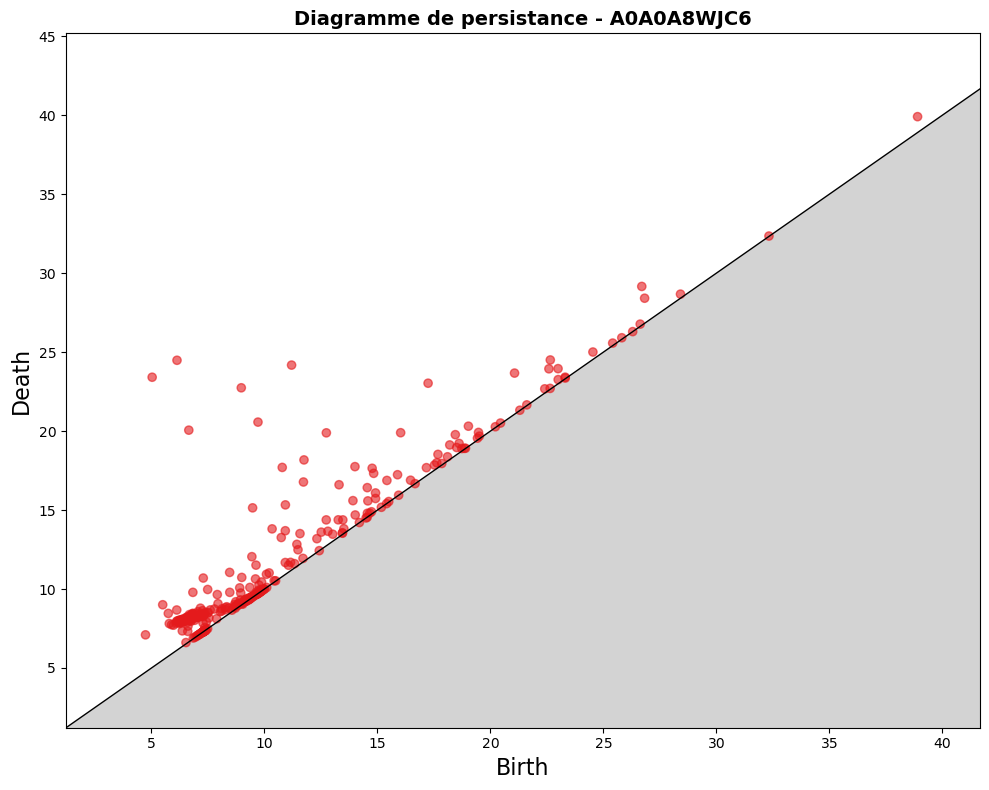


 Diagramme de persistance - A0A0K3AT43


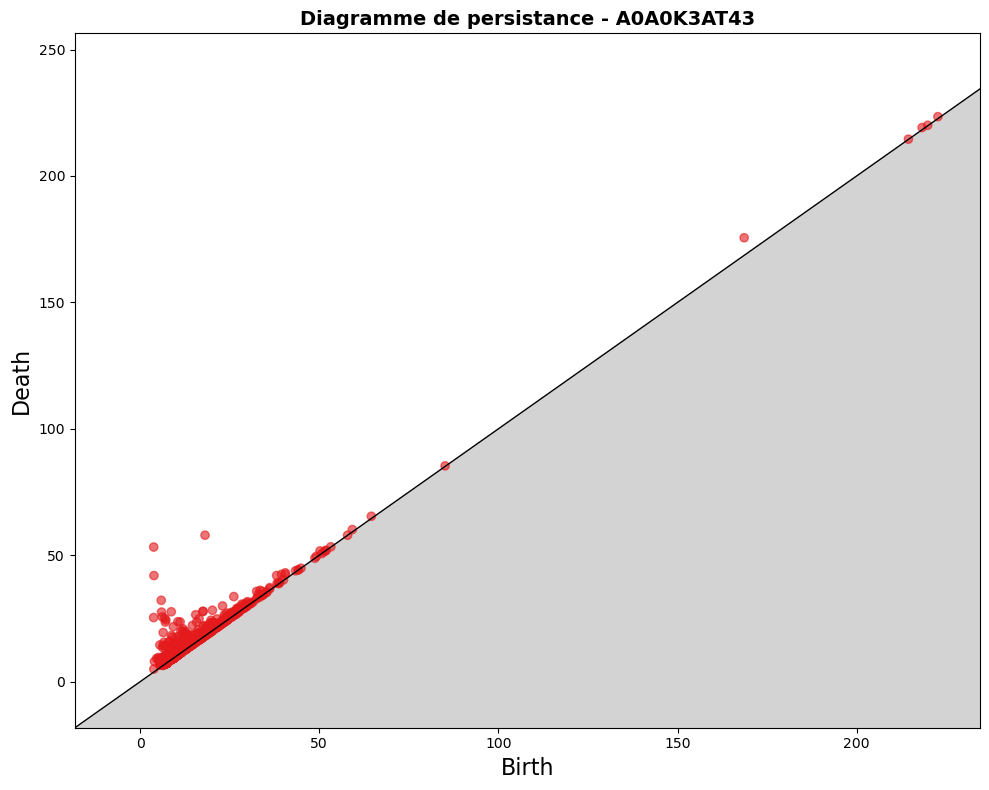


 Barcode - A0A0A8WJC6


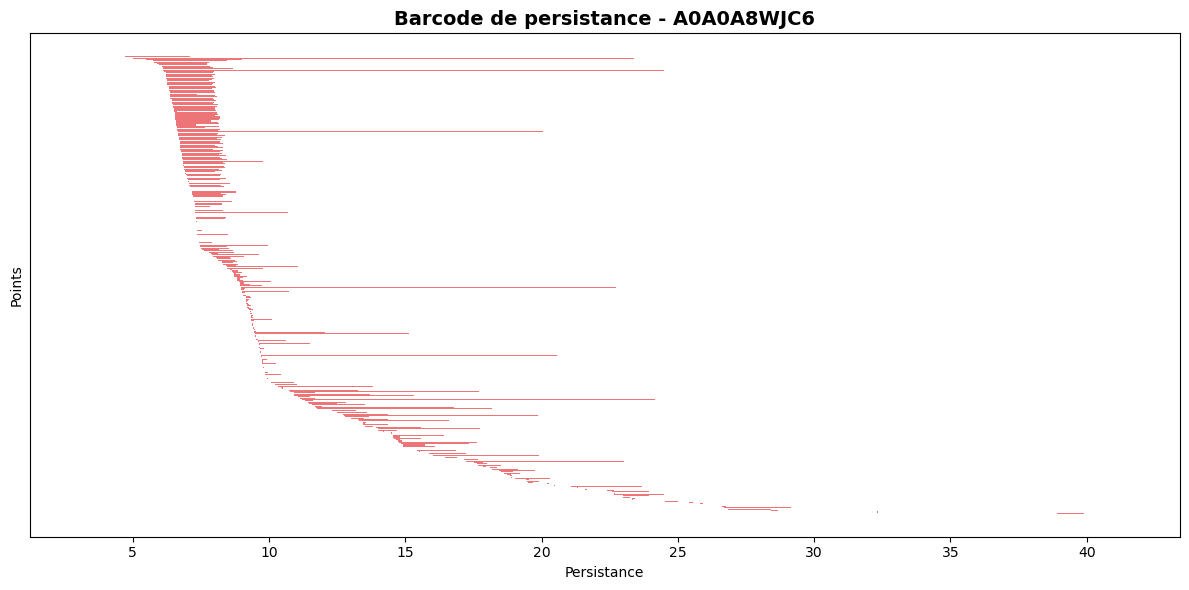


 Barcode - A0A0K3AT43


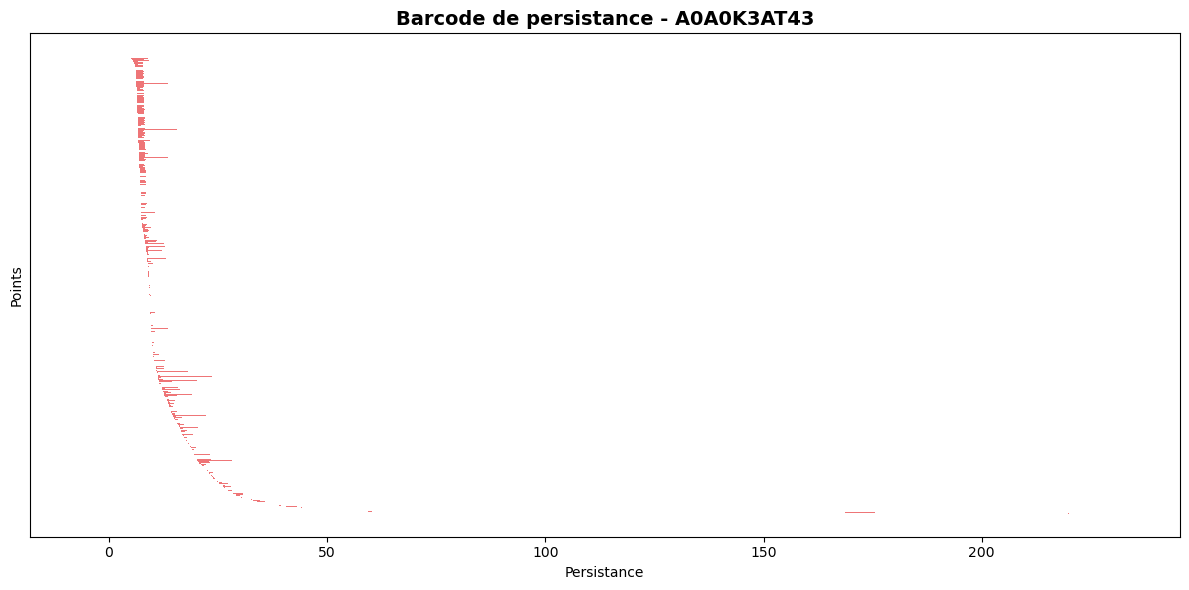

{'proteine1': 'A0A0A8WJC6',
 'proteine2': 'A0A0K3AT43',
 'longueur1': 136,
 'longueur2': 546,
 'points_diagram1': 342,
 'points_diagram2': 1412,
 'wasserstein_2': np.float64(48.47179849283095),
 'wasserstein_1': np.float64(683.6267876434058),
 'bottleneck': 24.07904975307658,
 'diagram1': array([[ 6.52640705,  6.61022036],
        [ 6.85034416,  6.89710833],
        [ 6.91852507,  6.94576301],
        [ 6.99181264,  7.00765733],
        [ 7.04030868,  7.05676739],
        [ 7.0535531 ,  7.07503712],
        [ 4.73489923,  7.09854423],
        [ 7.13516677,  7.14513248],
        [ 7.13228584,  7.14579626],
        [ 7.14724354,  7.15556471],
        [ 7.21655575,  7.22392291],
        [ 7.24193008,  7.2482692 ],
        [ 7.25436134,  7.25679025],
        [ 7.26728778,  7.26852863],
        [ 7.27907105,  7.28418651],
        [ 7.28422383,  7.28644514],
        [ 7.28610107,  7.28728817],
        [ 7.29324617,  7.29689903],
        [ 6.60521556,  7.31770544],
        [ 7.31765303,  7.31

In [13]:
compare_proteines(1, 2)


COMPARAISON DE DEUX PROTÉINES
 Position 1 → Code: A0A0A8WJC6
 Position 7 → Code: A0AAJ7U215

 Traitement de A0A0A8WJC6...

 Traitement de A0AAJ7U215...

DISTANCES ENTRE DIAGRAMMES DE PERSISTANCE
Distance de Wasserstein (ordre 2) : 7.8292
Distance de Wasserstein (ordre 1) : 80.8471
 Distance Bottleneck : 2.8203

 INTERPRÉTATION (Wasserstein-2):
Pourcentage de similitude : 20.9%
Interprétation : Les deux protéines sont DIFFÉRENTES
Plus la distance de wasserstein est petite, plus les protéines sont similaires

CARACTÉRISTIQUES COMPARÉES
Caractéristique           Protéine 1                     Protéine 2                    
---------------------------------
Code                      A0A0A8WJC6                     A0AAJ7U215                    
Fichier PDB               AF-A0A0A8WJC6-F1-model_v6.pdb  AF-A0AAJ7U215-F1-model_v6.pdb 
Longueur (aa)             136                            165                           
Nb atomes CA              136                            165             

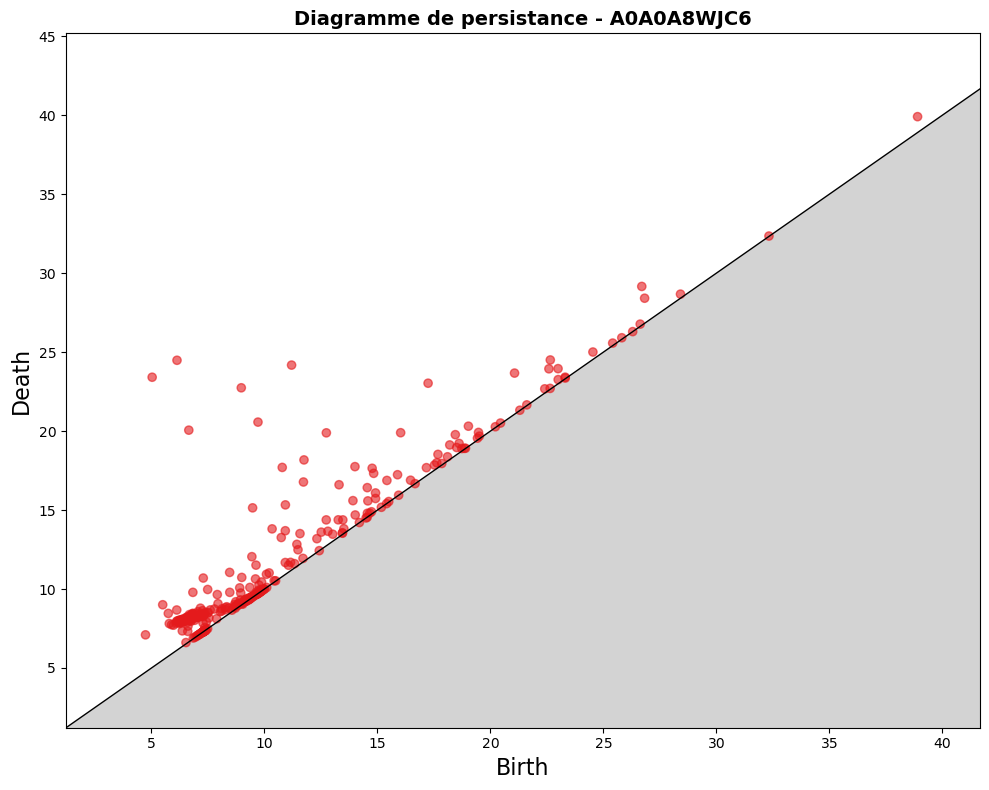


 Diagramme de persistance - A0AAJ7U215


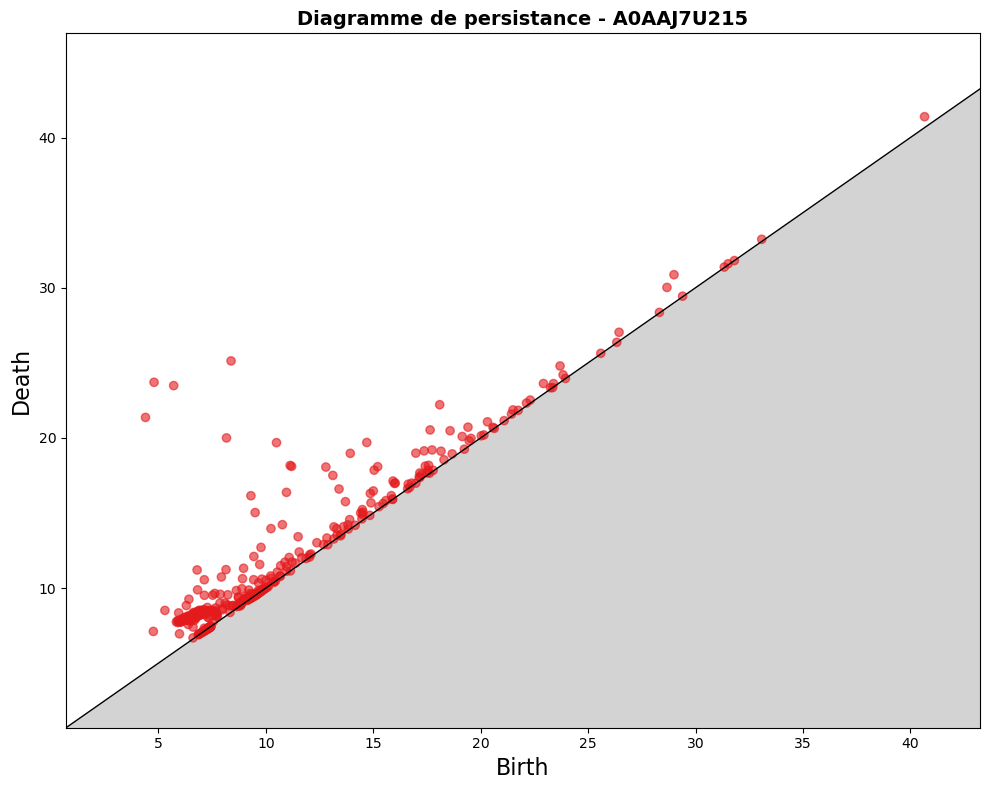


 Barcode - A0A0A8WJC6


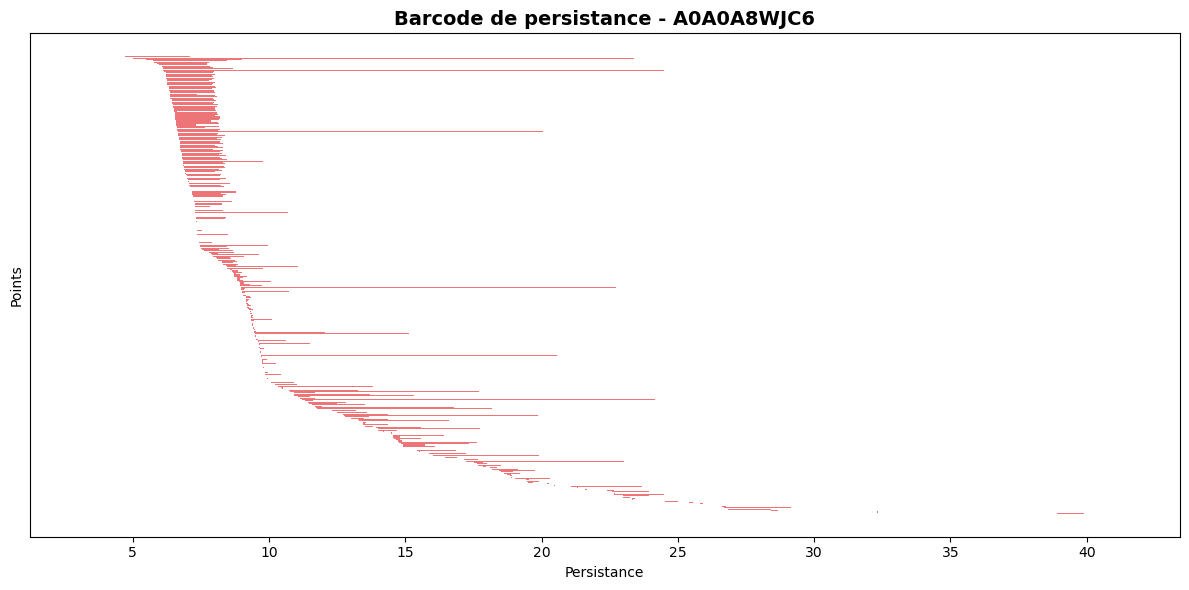


 Barcode - A0AAJ7U215


KeyboardInterrupt: 

In [14]:
compare_proteines(1,7)

**Comparaison à grnade échelle** on utilise la fonction précédente pour comparer 2 à 2 chaque protéïne, en présentant les résultats sous forme matrice contenant les pourcentages de similitude entre les protéïnes listées en ligne et en colonne. 
Le résultat attendu est une matrice symétrique dont les valeurs diagonales sont de 100% et la matrice est carrée de taille n*n avec n le nombre total de protéines comparées.

ensuite nous allons pouvoir repérer un pourcentage élevé proche de 99% entre deux protéines distinctes dont nous afficherons les barcodes avec un appel simple de la fonction de comparaison.

**limites** parcourir une matrice en On2 est coûteux en mémoire, on peut se restreindre à des comparaisons de petits groupes de protéïnes par exemple en comparer 20 entre elles seulement.

ouvrir le terminal de VS code et exécuter "pixi add pandas seaborn tqdm "

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
def quick_compare(limit=10, formula='exponential', scale=5):
   
    from tqdm import tqdm
    codes = list(proteines.keys())[:limit]
    n = len(codes)
    mat = np.zeros((n, n))
    
    for i in range(n):
        mat[i, i] = 100
    
    for i in tqdm(range(n)):
        for j in range(i+1, n):
            p1, p2 = get_proteine(codes[i]), get_proteine(codes[j])
            if p1 and p2 and p1.fichier_existe and p2.fichier_existe:
                try:
                   
                    was = compare_proteines(codes[i], codes[j])['wasserstein_2']
                    dist = was if was else 100
                    sim = 100 * np.exp(-dist/scale) if formula == 'exponential' else 100/(1+dist/scale)
                    
                except:
                    sim = 0
            else:
                sim = 0
            mat[i, j] = mat[j, i] = sim
    
    df = pd.DataFrame(mat, index=codes, columns=codes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100)
    plt.title('Matrice de similitude')
    plt.show()
    return df

# Utilisation
# mat_similitude = quick_compare(limit=8)

In [ ]:


def quick_compare(limit=10, formula='exponential', scale=5):
    from tqdm import tqdm
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    codes = list(proteines.keys())[:limit]
    n = len(codes)
    mat = np.zeros((n, n))
    
    for i in range(n):
        mat[i, i] = 100
    
    print(f"Calcul des similitudes pour {n} proteines...")
    
    succes_count = 0
    echec_count = 0
    
    for i in tqdm(range(n)):
        for j in range(i+1, n):
            try:
                dist = wasserstein_proteines(codes[i], codes[j])

                ## on a recours ici à la fonction définie précédemment
                ## elle retourne la distance de wasserstein à partir de 2 codes de protéines
                
                if dist is not None and dist > 0:
                    if formula == 'exponential':
                        sim = 100 * np.exp(-dist/scale)
                    else:
                        sim = 100 / (1 + dist/scale)
                    succes_count += 1
                else:
                    sim = 0
                    echec_count += 1
            except:
                sim = 0
                echec_count += 1
            
            mat[i, j] = sim
            mat[j, i] = sim
    
    print(f"\nResultats: {succes_count} succes, {echec_count} echecs")
    
    if succes_count > 0:
        print("\nVerification des resultats (premieres paires):")
        count = 0
        for i in range(min(5, n)):
            for j in range(i+1, min(6, n)):
                if mat[i, j] > 0 and count < 5:
                    print(f"  {codes[i]} vs {codes[j]}: {mat[i, j]:.1f}%")
                    count += 1
    


    df = pd.DataFrame(mat, index=codes, columns=codes)
    plt.figure(figsize=(12, 10))
    sns.heatmap(df, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100)
    plt.title(f'Matrice de similitude - {succes_count} comparaisons reussies')
    plt.tight_layout()
    plt.show()
    return df
    

    ## le résultat est stocké sous forme de matrice dans la variable mat_similitude
    ## modifier la valeur de limit=20 permet de calculer plus rapidement mais sur un plus petit echantillon

In [ ]:
mat_similitude = quick_compare(limit=160)

print(mat_similitude)

Calcul des similitudes pour 153 proteines...


100%|██████████| 153/153 [41:29<00:00, 16.27s/it] 



Resultats: 11628 succes, 0 echecs

Verification des resultats (premieres paires):
  A0A0A8WJC6 vs A0A0K3AT43: 0.0%
  A0A0A8WJC6 vs A0A2H4ZEZ2: 0.0%
  A0A0A8WJC6 vs A0AAJ7SV95: 0.0%
  A0A0A8WJC6 vs A0AAJ7T5N9: 0.0%
  A0A0A8WJC6 vs A0AAJ7TMY1: 0.0%
Calcul des similitudes pour 153 proteines...


100%|██████████| 153/153 [5:15:50<00:00, 123.86s/it]    



Resultats: 11628 succes, 0 echecs

Verification des resultats (premieres paires):
  A0A0A8WJC6 vs A0A0K3AT43: 0.0%
  A0A0A8WJC6 vs A0A2H4ZEZ2: 0.0%
  A0A0A8WJC6 vs A0AAJ7SV95: 0.0%
  A0A0A8WJC6 vs A0AAJ7T5N9: 0.0%
  A0A0A8WJC6 vs A0AAJ7TMY1: 0.0%
Calcul des similitudes pour 153 proteines...


  2%|▏         | 3/153 [02:11<1:46:09, 42.47s/it]

: 

In [ ]:
from tqdm import tqdm
def compute_wasserstein_matrix(limit=160, verbose=False):
   
    codes = list(proteines.keys())[:limit]
    n = len(codes)
    
    # Initialiser la matrice
    matrix = [['Err' for _ in range(n)] for _ in range(n)]
    
    for i in range(n):
        matrix[i][i] = 0.0
    
    # Pre-calculer les diagrammes
    if verbose:
        print("Pre-calcul des diagrammes...")
    
    diagrams = {}
    iterator = tqdm(codes) if verbose else codes
    
    for code in iterator:
        try:
            p = get_proteine(code)
            if p and p.fichier_existe:
                parser = PDBParser(PERMISSIVE=1)
                prot = parser.get_structure(id=0, file=p.chemin.open("r"))
                ca = extract_ca_atom_pos(list(prot))
                
                if len(ca) > 0:
                    
                    cech = gd.DelaunayCechComplex(points=ca)
                    st = cech.create_simplex_tree()
                    st.compute_persistence()
                    
                    # Utiliser la dimension 1 (distance de wasserstein mermettant des comparaisons précises)
                    diag_raw = st.persistence_intervals_in_dimension(1)
                    
                    # Filtrer et convertir en numpy array
                    diag = np.array([[d[0], d[1]] for d in diag_raw if d[1] != float('inf')])
                    
                    diagrams[code] = diag if len(diag) > 0 else np.array([]).reshape(0, 2)
                else:
                    diagrams[code] = np.array([]).reshape(0, 2)
            else:
                diagrams[code] = np.array([]).reshape(0, 2)
        except Exception as e:
            if verbose:
                print(f"Erreur pour {code}: {e}")
            diagrams[code] = np.array([]).reshape(0, 2)
    
    
    if verbose:
        print("\nCalcul des distances de Wasserstein...")
    
    iterator = tqdm(range(n)) if verbose else range(n)
    
    for i in iterator:
        for j in range(i+1, n):
            try:
                d1 = diagrams.get(codes[i], np.array([]).reshape(0, 2))
                d2 = diagrams.get(codes[j], np.array([]).reshape(0, 2))
                
                if len(d1) > 0 and len(d2) > 0:
                    from gudhi.wasserstein import wasserstein_distance
                    dist = wasserstein_distance(d1, d2, order=2)
                    matrix[i][j] = round(dist, 6)
                    matrix[j][i] = round(dist, 6)
                else:
                    matrix[i][j] = 'Err'
                    matrix[j][i] = 'Err'
            except Exception as e:
                if verbose:
                    print(f"Erreur {codes[i]} vs {codes[j]}: {e}")
                matrix[i][j] = 'Err'
                matrix[j][i] = 'Err'
    
    return matrix, codes

# Utilisation
matrix, codes = compute_wasserstein_matrix(limit=160, verbose=True)

# Affichage
print("\n" + "="*100)
print("MATRICE DES DISTANCES DE WASSERSTEIN")
print("="*100)
print(f"{'Proteine':<15}", end="")
for code in codes:
    print(f"{code[:12]:<13}", end="")
print()
print("-"* (15 + 13 * len(codes)))

for i, code_i in enumerate(codes):
    print(f"{code_i:<15}", end="")
    for j in range(len(codes)):
        val = matrix[i][j]
        if isinstance(val, float):
            print(f"{val:<13.4f}", end="")
        else:
            print(f"{val:<13}", end="")
    print()
print("="*100)

Pre-calcul des diagrammes...


100%|██████████| 153/153 [00:16<00:00,  9.10it/s]



Calcul des distances de Wasserstein...


  6%|▌         | 9/153 [02:10<29:48, 12.42s/it]

In [ ]:
print(matrix)


[[0.0, np.float64(48.471798), np.float64(38.417022), np.float64(496.734513), np.float64(190.111737), np.float64(132.524522), np.float64(7.829175), np.float64(430.813553), np.float64(9.745056), np.float64(34.179894), np.float64(171.006954), np.float64(15.13407), np.float64(12.10144), np.float64(206.678928), np.float64(11.057141), np.float64(9.57806), np.float64(9.607801), np.float64(49.14206), np.float64(12.116533), np.float64(35.117279), np.float64(80.061926), np.float64(324.070449), np.float64(10.193652), np.float64(10.983156), np.float64(24.402928), np.float64(10.796801), np.float64(10.467522), np.float64(21.951507), np.float64(9.306679), np.float64(10.836631), np.float64(11.202236), np.float64(8.698351), np.float64(8.83559), np.float64(80.477806), np.float64(12.853074), np.float64(8.630009), np.float64(20.649827), np.float64(10.775317), np.float64(11.238903), np.float64(9.874641), np.float64(209.308756), np.float64(11.00802), np.float64(571.716797), np.float64(107.753759), np.float6

In [ ]:
def find_min_non_zero(matrix):
    """
    Trouve la valeur minimale non nulle dans une matrice et ses coordonnees.
    
    Parametres:
        matrix: liste de listes contenant des nombres ou 'Err'
    
    Retourne:
        tuple: (min_value, i, j) ou (None, None, None) si aucun minimum non nul trouve
    """
    min_value = None
    min_i = None
    min_j = None
    
    for i in range(len(matrix)):
        for j in range(len(matrix[i])):
            val = matrix[i][j]
            # Verifier si c'est un nombre, non nul, et pas 'Err'
            if isinstance(val, (int, float)) and val != 0 and val != 'Err':
                if min_value is None or val < min_value:
                    min_value = val
                    min_i = i
                    min_j = j
    
    return min_value, min_i, min_j

In [ ]:
find_min_non_zero(matrix)

(np.float64(1.46231), 67, 145)

67 Q9I7P6
145 P02197
1.4623102820760523

COMPARAISON DE DEUX PROTÉINES

 Traitement de P02208...

 Traitement de Q9I9I3...

DISTANCES ENTRE DIAGRAMMES DE PERSISTANCE
Distance de Wasserstein (ordre 2) : 1.4623
Distance de Wasserstein (ordre 1) : 18.6752
 Distance Bottleneck : 0.4356

 INTERPRÉTATION (Wasserstein-2):
Pourcentage de similitude : 74.6%
Interprétation : Les deux protéines sont SIMILAIRES
Plus la distance de wasserstein est petite, plus les protéines sont similaires

CARACTÉRISTIQUES COMPARÉES
Caractéristique           Protéine 1                     Protéine 2                    
---------------------------------
Code                      P02208                         Q9I9I3                        
Fichier PDB               AF-P02208-F1-model_v6.pdb      AF-Q9I9I3-F1-model_v6.pdb     
Longueur (aa)             150                            150                           
Nb atomes CA              150                            150                           
Points diagramme

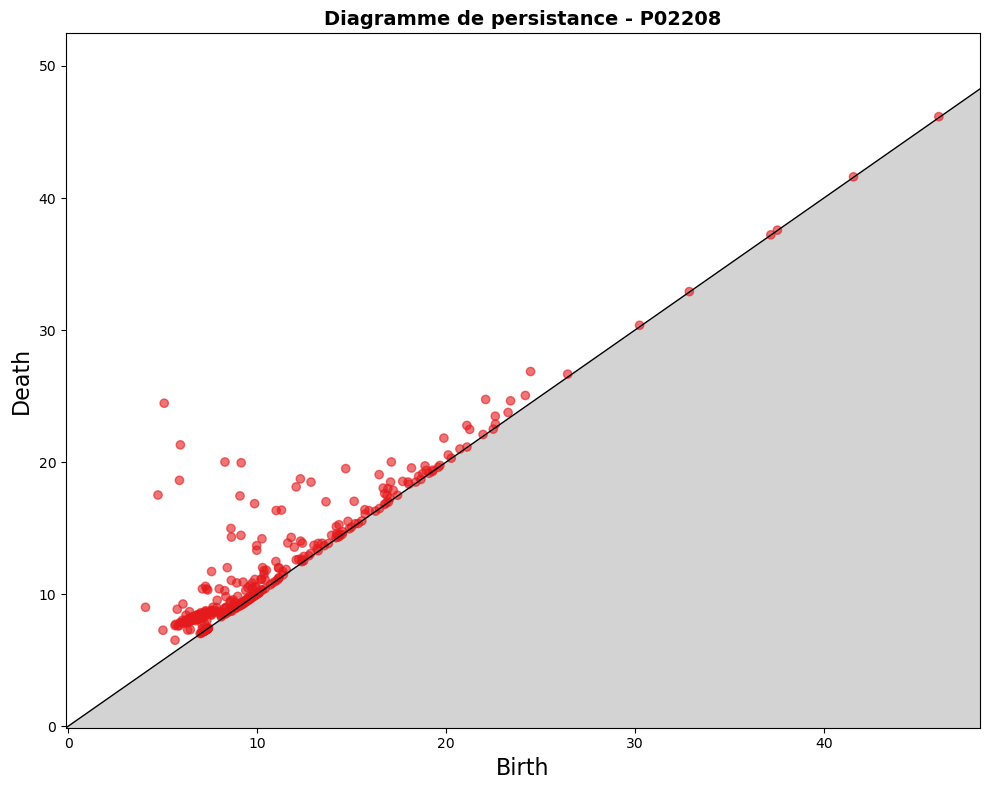


 Diagramme de persistance - Q9I9I3


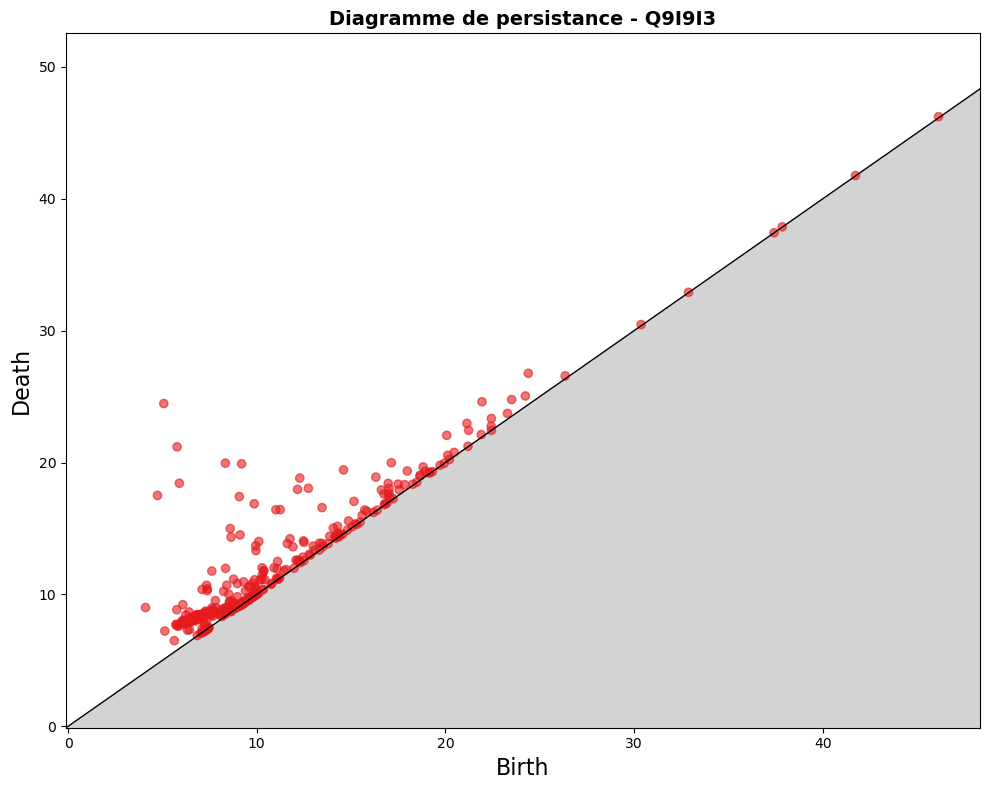


 Barcode - P02208


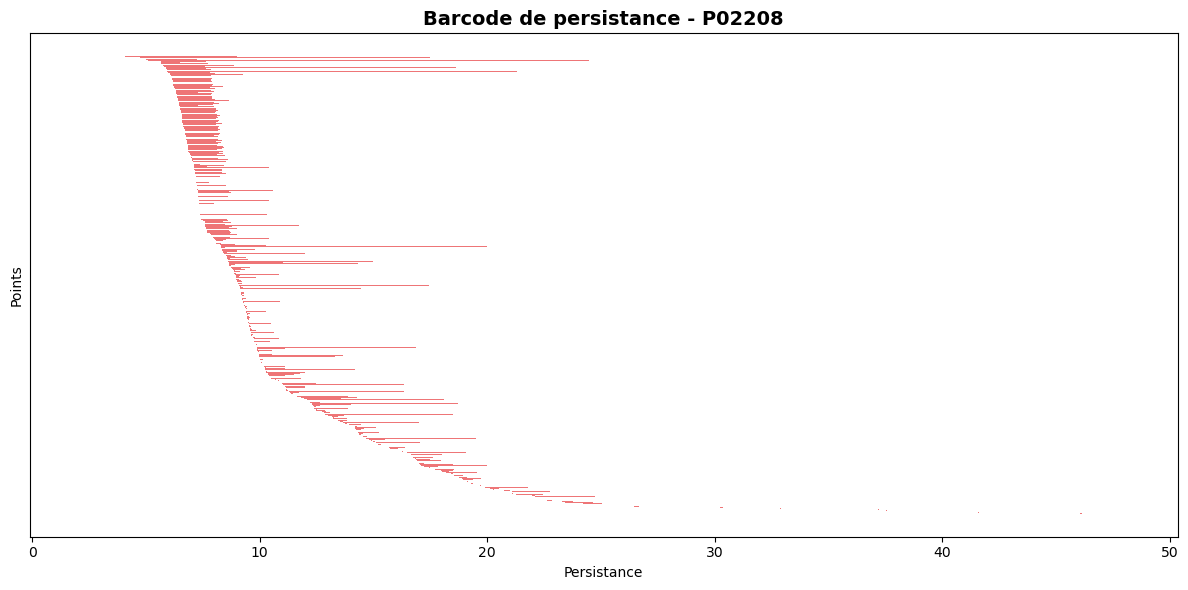


 Barcode - Q9I9I3


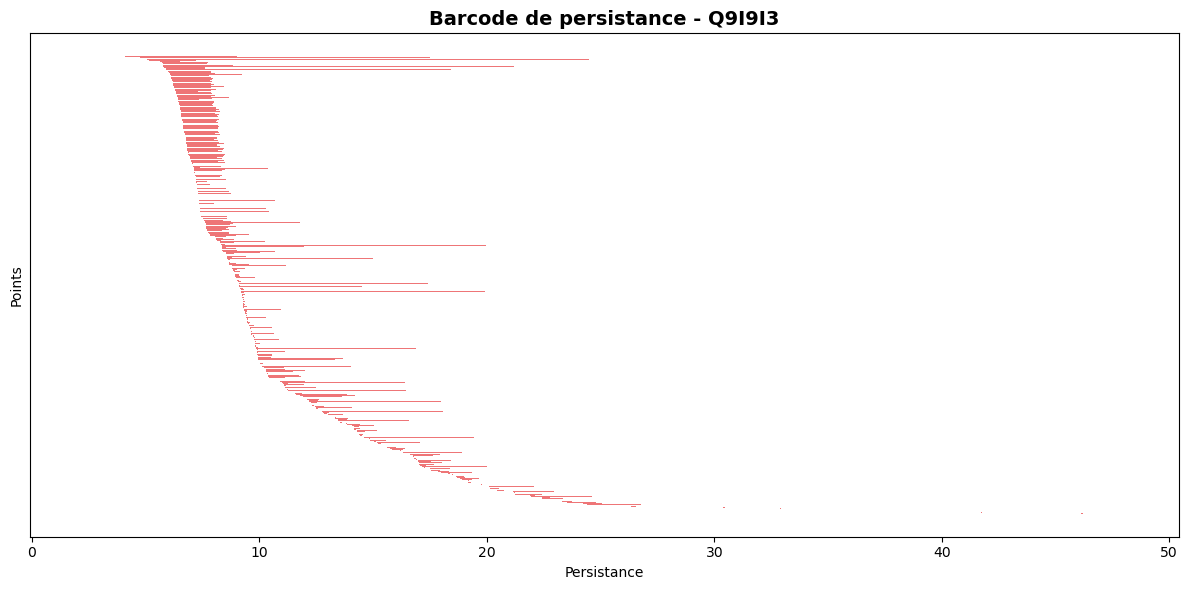

{'proteine1': 'P02208',
 'proteine2': 'Q9I9I3',
 'longueur1': 150,
 'longueur2': 150,
 'points_diagram1': 383,
 'points_diagram2': 381,
 'wasserstein_2': np.float64(1.4623102820760523),
 'wasserstein_1': np.float64(18.675164425230633),
 'bottleneck': 0.43557368484647796,
 'diagram1': array([[ 5.6548029 ,  6.51245912],
        [ 6.98439671,  7.01352337],
        [ 7.04063887,  7.05475053],
        [ 7.06479005,  7.07650556],
        [ 7.15897968,  7.17164657],
        [ 7.1810292 ,  7.1877395 ],
        [ 7.20394285,  7.21042191],
        [ 7.20349685,  7.21184289],
        [ 7.20885884,  7.21393477],
        [ 7.21555826,  7.22366051],
        [ 7.22888457,  7.23440341],
        [ 7.23473109,  7.23795242],
        [ 7.24845991,  7.2511222 ],
        [ 7.25762912,  7.26010253],
        [ 5.0167336 ,  7.26749451],
        [ 7.26674432,  7.26915725],
        [ 6.3235485 ,  7.2851279 ],
        [ 7.28942041,  7.29481656],
        [ 7.29936544,  7.30158292],
        [ 6.46419258,  7.3086451

In [ ]:
print(find_min_non_zero(matrix)[1], get_code(find_min_non_zero(matrix)[2]))
print(find_min_non_zero(matrix)[2], get_code(find_min_non_zero(matrix)[1]))
print(wasserstein_proteines(get_code(find_min_non_zero(matrix)[1]+1),get_code(find_min_non_zero(matrix)[2]+1)))
compare_proteines(get_code(find_min_non_zero(matrix)[1]+1),get_code(find_min_non_zero(matrix)[2]+1))
##ATTENTION bien rajouter +1 car les indexes de la matrices vont de 0 à n-1 et les indexes des proteines de 1 à n

on remarque que la distance de wasserstein entre  Q9I7P6 et  P02197 est de 1.4623 ce qui est très faible.
les deux protéines sont donc très proches et nous pouvons calculer leur pourcentage de similitude (74.6%)
en les comparant à l'aide de la fonction de comparaison précédente.

pour obtenir les valeurs minimales, strictement supérieures à zéro de distances de wasserstein dans la matrice il suffit d'y appliquer la fonction min. le plus petit élément ainsi retourné a pour coordonnées i j les indices des protéines.
Or, la fonction get_code(integer) définie au début nous permet alors d'obtenir les codes des protéines
qui sont très similaires avec cette distance de wasserstein faible.

Enfin, l'idée serait d'utiliser les résultats de cette matrice pour obtenir un arbre philogénique des protéines,
les regroupant alors par niveau de similarité de conformation 3D (déterminée par la distance de wasserstein).

In [ ]:
class ArbrePhylogenetique:
    def __init__(self, valeur, nom_proteine=None):
        self.valeur = valeur  # la distance de wasserstein
        self.nom_proteine = nom_proteine  # nom de la protéine pour les feuilles
        self.enfants = []  # liste des enfants (nombre illimité)

    def ajouter_enfant(self, enfant):
        """Ajoute un enfant à l'noeud courant"""
        self.enfants.append(enfant)

    def get_valeur(self):
        return self.valeur

    def get_nom(self):
        return self.nom_proteine

    def get_enfants(self):
        return self.enfants

    def est_feuille(self):
        return len(self.enfants) == 0 


In [ ]:
def construire_arbre_phylogenetique(matrix):
    """
    Construit un arbre phylogénétique à partir d'une matrice de distances de Wasserstein 2.
    
    Args:
        matrix: matrice carrée des distances de Wasserstein 2
        
    Returns:
        ArbrePhylogenetique: racine de l'arbre construit
    """
    import numpy as np
    
    # Initialisation : chaque protéine est une feuille
    len_mat = len(matrix)
    liste = list(range(len_mat + 1))
    # liste allant de o à n contenant n+1 elems
    noms_proteines = [get_code(k+1) for k in liste]
    # ici indices allant de 1 à n+1 
    noeuds = [ArbrePhylogenetique(0, nom) for nom in noms_proteines]
    # on parcours la liste des noms de protéines 
    indices = list(range(len(noeuds)))
    distances = matrix.copy()
    
    # Algorithme de clustering hiérarchique (UPGMA simplifié)
    while len(noeuds) > 1:
        # Trouver la paire de protéines/nœuds la plus proche
        min_dist = np.inf
        min_i, min_j = -1, -1
        
        for i in range(len(distances)):
            for j in range(i+1, len(distances)):
                # on s'est assurés que i != j 
                # sinon la distance est nulle, la proteine est la même
                if distances[i][j] < min_dist:
                    min_dist = distances[i][j]
                    min_i, min_j = i, j
        
        # Créer un nouveau nœud parent pour cette paire
        nouveau_parent = ArbrePhylogenetique(min_dist / 2.0)
        nouveau_parent.ajouter_enfant(noeuds[min_i])
        nouveau_parent.ajouter_enfant(noeuds[min_j])
        
        # Mettre à jour les structures
        nouveaux_noeuds = [nouveau_parent]
        nouveaux_indices = [min_i]  # indice virtuel pour le nouveau nœud
        
        for k in range(len(noeuds)):
            if k != min_i and k != min_j:
                nouveaux_noeuds.append(noeuds[k])
                nouveaux_indices.append(k)
        
        # Mettre à jour la matrice de distances (méthode de liaison simple)
        nouvelle_distances = []
        n = len(nouveaux_noeuds)
        
        for i in range(n):
            nouvelle_distances.append([0.0] * n)
        
        # Calculer les nouvelles distances
        for i in range(n):
            for j in range(i+1, n):
                if i == 0 and j == 0:
                    continue
                elif i == 0:  # distance du nouveau nœud vers l'ancien nœud j
                    idx_j = nouveaux_indices[j]
                    dist = min(distances[min_i][idx_j], distances[min_j][idx_j])
                    nouvelle_distances[i][j] = dist
                    nouvelle_distances[j][i] = dist
                else:  # distance entre deux anciens nœuds
                    idx_i = nouveaux_indices[i]
                    idx_j = nouveaux_indices[j]
                    nouvelle_distances[i][j] = distances[idx_i][idx_j]
                    nouvelle_distances[j][i] = distances[idx_i][idx_j]
        
        distances = nouvelle_distances
        noeuds = nouveaux_noeuds
    
    return noeuds[0] if noeuds else None



In [ ]:
construire_arbre_phylogenetique(matrix)

IndexError: list index out of range

In [ ]:

def afficher_arbre(arbre, niveau=0):
    """Affiche l'arbre phylogénétique de manière hiérarchique"""
    if arbre is None:
        return
    
    indent = "  " * niveau
    if arbre.nom_proteine:
        print(f"{indent}├─ {arbre.nom_proteine} (dist: {arbre.valeur:.3f})")
    else:
        print(f"{indent}├─ Noeud interne (dist: {arbre.valeur:.3f})")
    
    for enfant in arbre.get_enfants():
        afficher_arbre(enfant, niveau + 1)




In [ ]:
def trouver_proteines_sous_noeud(arbre, noms_proteines=None):
    """Trouve toutes les protéines sous un nœud donné"""
    if noms_proteines is None:
        noms_proteines = []
    
    if arbre.nom_proteine:
        noms_proteines.append(arbre.nom_proteine)
    else:
        for enfant in arbre.get_enfants():
            trouver_proteines_sous_noeud(enfant, noms_proteines)
    
    return noms_proteines



In [ ]:

# Exemple d'utilisation :
if __name__ == "__main__":
    import numpy as np
    
    # Construction de l'arbre phylogénétique
    arbre_phylogenique = construire_arbre_phylogenetique(matrix, noms_proteines)
    
    # Affichage de l'arbre
    print("Arbre phylogénétique des protéines :")
    afficher_arbre(arbre_phylogenique)
    
    # Exemple : trouver toutes les protéines sous un nœud spécifique
    if arbre_phylogenique and not arbre_phylogenique.est_feuille():
        proteines = trouver_proteines_sous_noeud(arbre_phylogenique)
        print(f"\nToutes les protéines dans l'arbre : {proteines}")

In [ ]:
def afficher_arbre_compact(arbre, max_proteines=5):

    #Args:
        #arbre: nœud de l'arbre
        #max_proteines: nombre max de protéines à détailler par cluster
 
    if arbre is None:
        return
    
    def _afficher_compact(noeud, profondeur=0, prefix=""):
        if noeud.nom_proteine:
            # Feuille : protéine individuelle
            print(f"{prefix}• {noeud.nom_proteine}")
        else:
            # Nœud interne
            proteines = trouver_proteines_sous_noeud(noeud)
            nb_proteines = len(proteines)
            
            if nb_proteines <= max_proteines:
                # Petit cluster : afficher toutes les protéines
                print(f"{prefix} Cluster ({nb_proteines} protéines): {', '.join(proteines)}")
            else:
                # Gros cluster : afficher un résumé
                print(f"{prefix} Cluster ({nb_proteines} protéines): {', '.join(proteines[:max_proteines])}...")
                
                # Afficher les sous-clusters avec indentation
                nouveau_prefix = prefix + "  "
                for enfant in noeud.get_enfants():
                    _afficher_compact(enfant, profondeur + 1, nouveau_prefix)
    
    print("=====")
    print("ARBRE PHYLOGÉNÉTIQUE DES PROTÉINES")
    print("=====")
    _afficher_compact(arbre)
    print("=====")

In [ ]:
find_min_non_zero(matrix)

